In [1]:
!pip install kaggle

In [2]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [3]:
!kaggle datasets download -d omkargurav/face-mask-dataset

Dataset URL: https://www.kaggle.com/datasets/omkargurav/face-mask-dataset
License(s): unknown
 84% 137M/163M [00:00<00:00, 249MB/s]
100% 163M/163M [00:00<00:00, 230MB/s]


In [4]:
from zipfile import ZipFile
dataset = '/content/face-mask-dataset.zip'

with ZipFile(dataset,'r') as zip:
  zip.extractall()
  print('Done')

Done


In [5]:
!ls

data  face-mask-dataset.zip  kaggle.json  sample_data


In [6]:
#import the dependencies
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.pyplot as mpimg
import cv2
from google.colab.patches import cv2_imshow
from PIL import Image
from sklearn.model_selection import train_test_split

In [7]:
with_mask_files = os.listdir('/content/data/with_mask')
without_mask_files = os.listdir('/content/data/without_mask')
print(len(with_mask_files))
print(len(without_mask_files))

3725
3828


In [8]:
print(with_mask_files[:5])
print(without_mask_files[:5])

['with_mask_873.jpg', 'with_mask_359.jpg', 'with_mask_3200.jpg', 'with_mask_3440.jpg', 'with_mask_2707.jpg']
['without_mask_3332.jpg', 'without_mask_2402.jpg', 'without_mask_791.jpg', 'without_mask_775.jpg', 'without_mask_706.jpg']


In [9]:
#Create lables for the two class of images

with_mask_labels = [1]*3725
without_mask_labels = [0]*3828

In [10]:
print(with_mask_labels[:5])
print(without_mask_labels[:5])

[1, 1, 1, 1, 1]
[0, 0, 0, 0, 0]


In [11]:
print(len(with_mask_labels))
print(len(without_mask_labels))

3725
3828


In [12]:
labels = with_mask_labels + without_mask_labels
print(len(labels))

7553


In [13]:
3725 + 3828

7553

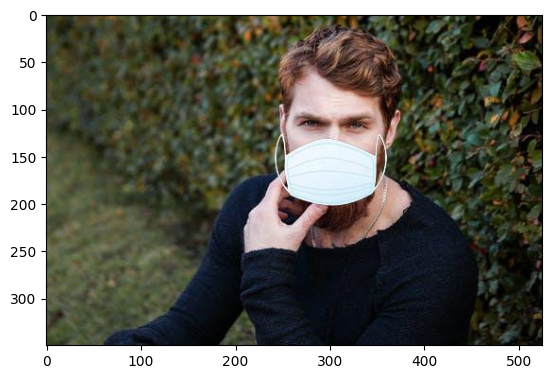

In [14]:
#Displaying the image of mask
img = mpimg.imread('/content/data/with_mask/with_mask_1.jpg')
imgplot = plt.imshow(img)
plt.show()

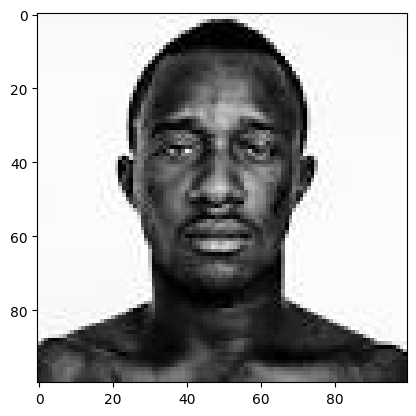

In [15]:
#Displaying the image of without mask
img = mpimg.imread('/content/data/without_mask/without_mask_1.jpg')
imgplot = plt.imshow(img)
plt.show()

In [16]:
with_mask_path = '/content/data/with_mask/'


data = []

for img_file in with_mask_files:
  image = Image.open(with_mask_path + img_file)
  image = image.resize((128,128))
  image = image.convert('RGB')
  image = np.array(image)
  data.append(image)

without_mask_path = '/content/data/without_mask/'

for img_file in without_mask_files:
  image = Image.open(without_mask_path + img_file)
  image = image.resize((128,128))
  image = image.convert('RGB')
  image = np.array(image)
  data.append(image)


/usr/local/lib/python3.10/dist-packages/PIL/Image.py:1056: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


In [17]:
type(data)
len(data)

7553

array([[[211, 223, 211],
        [214, 226, 214],
        [213, 225, 214],
        ...,
        [233, 249, 246],
        [232, 248, 245],
        [231, 247, 244]],

       [[220, 231, 217],
        [225, 236, 221],
        [223, 235, 221],
        ...,
        [233, 249, 246],
        [232, 248, 245],
        [231, 247, 244]],

       [[220, 229, 213],
        [223, 232, 216],
        [222, 230, 215],
        ...,
        [233, 249, 246],
        [232, 248, 245],
        [231, 247, 244]],

       ...,

       [[ 99,  47,  40],
        [103,  52,  44],
        [107,  58,  50],
        ...,
        [205, 145, 116],
        [206, 146, 117],
        [207, 147, 118]],

       [[105,  50,  34],
        [112,  58,  42],
        [118,  64,  49],
        ...,
        [204, 145, 113],
        [206, 147, 115],
        [207, 148, 116]],

       [[121,  65,  48],
        [133,  77,  61],
        [143,  87,  72],
        ...,
        [204, 145, 112],
        [206, 147, 115],
        [207, 148, 116]]], dtype=uint8)
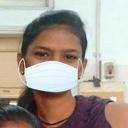

In [18]:
data[0]

In [19]:
type(data[0])

numpy.ndarray

In [20]:
#COnvert the labels and image list to numpy array
X = np.array(data)
Y = np.array(labels)

In [21]:
type(X)

numpy.ndarray

In [22]:
X.shape

(7553, 128, 128, 3)

In [23]:
#train and test the data
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)

In [24]:
len(X_train)

6042

In [25]:
X_train.shape

(6042, 128, 128, 3)

In [26]:
#Scale the data
X_train_scaled = X_train/255
X_test_scaled = X_test/255

In [27]:
#Building a CNN MODEL
import tensorflow as tf
from tensorflow import keras

In [28]:
num_of_classes = 2

model = keras.Sequential([
    keras.layers.Conv2D(32,kernel_size=(3,3),activation='relu',input_shape=(128,128,3)),
    keras.layers.MaxPooling2D((2,2)),

    keras.layers.Conv2D(64,kernel_size=(3,3),activation='relu'),
    keras.layers.MaxPooling2D((2,2)),

    keras.layers.Flatten(),
    keras.layers.Dense(128,activation='relu'),

    keras.layers.Dropout(0.5),
    keras.layers.Dense(64,activation='relu'),
    keras.layers.Dropout(0.5),

    keras.layers.Dense(num_of_classes,activation='sigmoid')
    #Softmax is mainly used for multi classification
    #Sigmoid is mainly use for binary classification

])

In [29]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [30]:
history = model.fit(X_train_scaled,Y_train,validation_split=0.1,epochs=5)

Epoch 1/5
170/170 [==============================] - 18s 101ms/step - loss: 0.4107 - accuracy: 0.8321 - val_loss: 0.2422 - val_accuracy: 0.8893
Epoch 2/5
170/170 [==============================] - 16s 95ms/step - loss: 0.2869 - accuracy: 0.8889 - val_loss: 0.1949 - val_accuracy: 0.9124
Epoch 3/5
170/170 [==============================] - 16s 93ms/step - loss: 0.2289 - accuracy: 0.9121 - val_loss: 0.1690 - val_accuracy: 0.9339
Epoch 4/5
170/170 [==============================] - 16s 94ms/step - loss: 0.1856 - accuracy: 0.9268 - val_loss: 0.1827 - val_accuracy: 0.9207
Epoch 5/5
170/170 [==============================] - 16s 94ms/step - loss: 0.1580 - accuracy: 0.9376 - val_loss: 0.1586 - val_accuracy: 0.9306


In [31]:
loss,accuracy = model.evaluate(X_test_scaled,Y_test)
print('Test Accuracy = ',accuracy)

48/48 [==============================] - 1s 24ms/step - loss: 0.1972 - accuracy: 0.9325
Test Accuracy =  0.9324950575828552


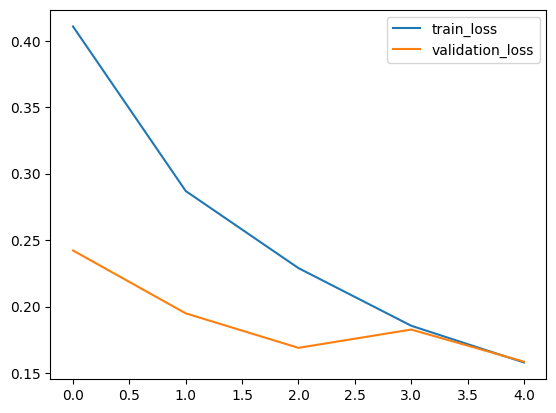

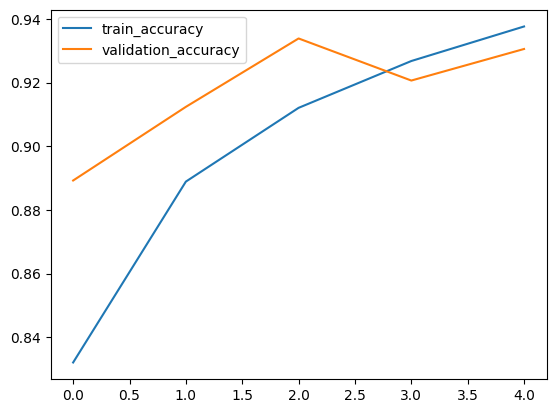

In [32]:
h = history

plt.plot(h.history['loss'],label='train_loss')
plt.plot(h.history['val_loss'],label='validation_loss')
plt.legend()
plt.show()

plt.plot(h.history['accuracy'],label='train_accuracy')
plt.plot(h.history['val_accuracy'],label='validation_accuracy')
plt.legend()
plt.show()

Enter the path of the image to be predicted: /content/mask.jpeg


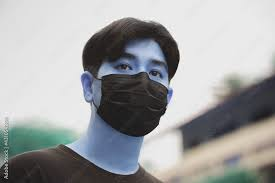

1/1 [==============================] - 0s 30ms/step
[[0.40156206 0.53084064]]
1
The person in the image is wearing a mask


In [34]:
#Predictive System
input_image_path = input("Enter the path of the image to be predicted: ")

input_image = Image.open(input_image_path)

# Convert PIL Image to NumPy array
input_image_np = np.array(input_image)

cv2_imshow(input_image_np) # Pass NumPy array to cv2_imshow

input_image_resized = cv2.resize(input_image_np,(128,128))
input_image_scaled = input_image_resized/255
input_image_reshaped = np.reshape(input_image_scaled,[1,128,128,3])

input_prediction = model.predict(input_image_reshaped)

print(input_prediction)

input_pred_label = np.argmax(input_prediction)

print(input_pred_label)

if input_pred_label == 1:
  print("The person in the image is wearing a mask")
else:
  print("The person in the image is not wearing a mask")

Enter the path of the image to be predicted: /content/mask1.jpeg


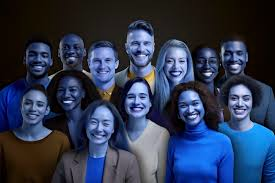

1/1 [==============================] - 0s 29ms/step
[[0.80401856 0.2024751 ]]
0
The person in the image is not wearing a mask


In [39]:
#Predictive System
input_image_path = input("Enter the path of the image to be predicted: ")

input_image = Image.open(input_image_path)

# Convert PIL Image to NumPy array
input_image_np = np.array(input_image)

cv2_imshow(input_image_np) # Pass NumPy array to cv2_imshow

input_image_resized = cv2.resize(input_image_np,(128,128))
input_image_scaled = input_image_resized/255
input_image_reshaped = np.reshape(input_image_scaled,[1,128,128,3])

input_prediction = model.predict(input_image_reshaped)

print(input_prediction)

input_pred_label = np.argmax(input_prediction)

print(input_pred_label)

if input_pred_label == 1:
  print("The person in the image is wearing a mask")
else:
  print("The person in the image is not wearing a mask")